![image](car.jpeg)

**Car-ing is sharing**, an auto dealership company for car sales and rental, is taking their services to the next level thanks to **Large Language Models (LLMs)**.

As their newly recruited AI and NLP developer, you've been asked to prototype a chatbot app with multiple functionalities that not only assist customers but also provide support to human agents in the company.

The solution should receive textual prompts and use a variety of pre-trained Hugging Face LLMs to respond to a series of tasks, e.g. classifying the sentiment in a car’s text review, answering a customer question, summarizing or translating text, etc.


Device set to use cpu


Dataset shape: (5, 2)
                                              Review     Class
0  I am very satisfied with my 2014 Nissan NV SL....  POSITIVE
1  The car is fine. It's a bit loud and not very ...  NEGATIVE
2  My first foreign car. Love it, I would buy ano...  POSITIVE
3  I've come across numerous reviews praising the...  NEGATIVE
4  I've been dreaming of owning an SUV for quite ...  POSITIVE

Columns: ['Review', 'Class']

[Task 1] Accuracy : 0.8000
[Task 1] F1 Score : 0.8571


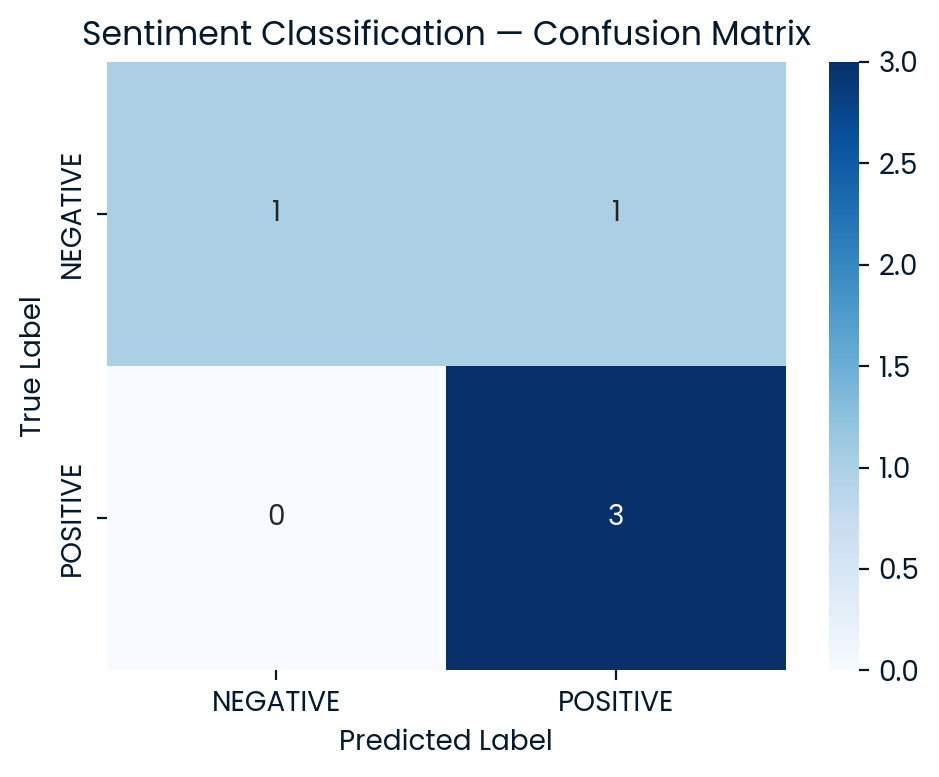

[Task 1] Confusion matrix saved → confusion_matrix.png

[Task 2] Source text: I am very satisfied with my 2014 Nissan NV SL. I use this van for my business deliveries and personal use.


Device set to use cpu


[Task 2] Translation : Estoy muy satisfecho con mi Nissan NV SL 2014. Uso esta camioneta para mis entregas de negocios y uso personal.


Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


[Task 2] BLEU Score : {'bleu': 0.7794483794144497, 'precisions': [0.9090909090909091, 0.8571428571428571, 0.75, 0.631578947368421], 'brevity_penalty': 1.0, 'length_ratio': 1.0476190476190477, 'translation_length': 22, 'reference_length': 21}

[Task 3] Question   : What did he like about the brand?
[Task 3] Answer     : ride quality, reliability
[Task 3] Confidence : 0.4774


Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



[Task 4] Original : I've been dreaming of owning an SUV for quite a while, but I've been driving cars that were already paid for during an extended period. I ultimately made the decision to transition to a brand-new car,...
[Task 4] Summary  : The Nissan Rogue provides me with the desired SUV experience without burdening me with an exorbitant payment. Handling and styling are great; I have hauled 12 bags of mulch in the back with the seats down and could have held more. The engine delivers strong


Device set to use cpu
Device set to use cpu


[Task 4] Max Toxicity : 0.0001
[Task 4] Regard       : [[{'label': 'positive', 'score': 0.6263338923454285}, {'label': 'neutral', 'score': 0.20273476839065552}, {'label': 'other', 'score': 0.12291575223207474}, {'label': 'negative', 'score': 0.04801557958126068}]]


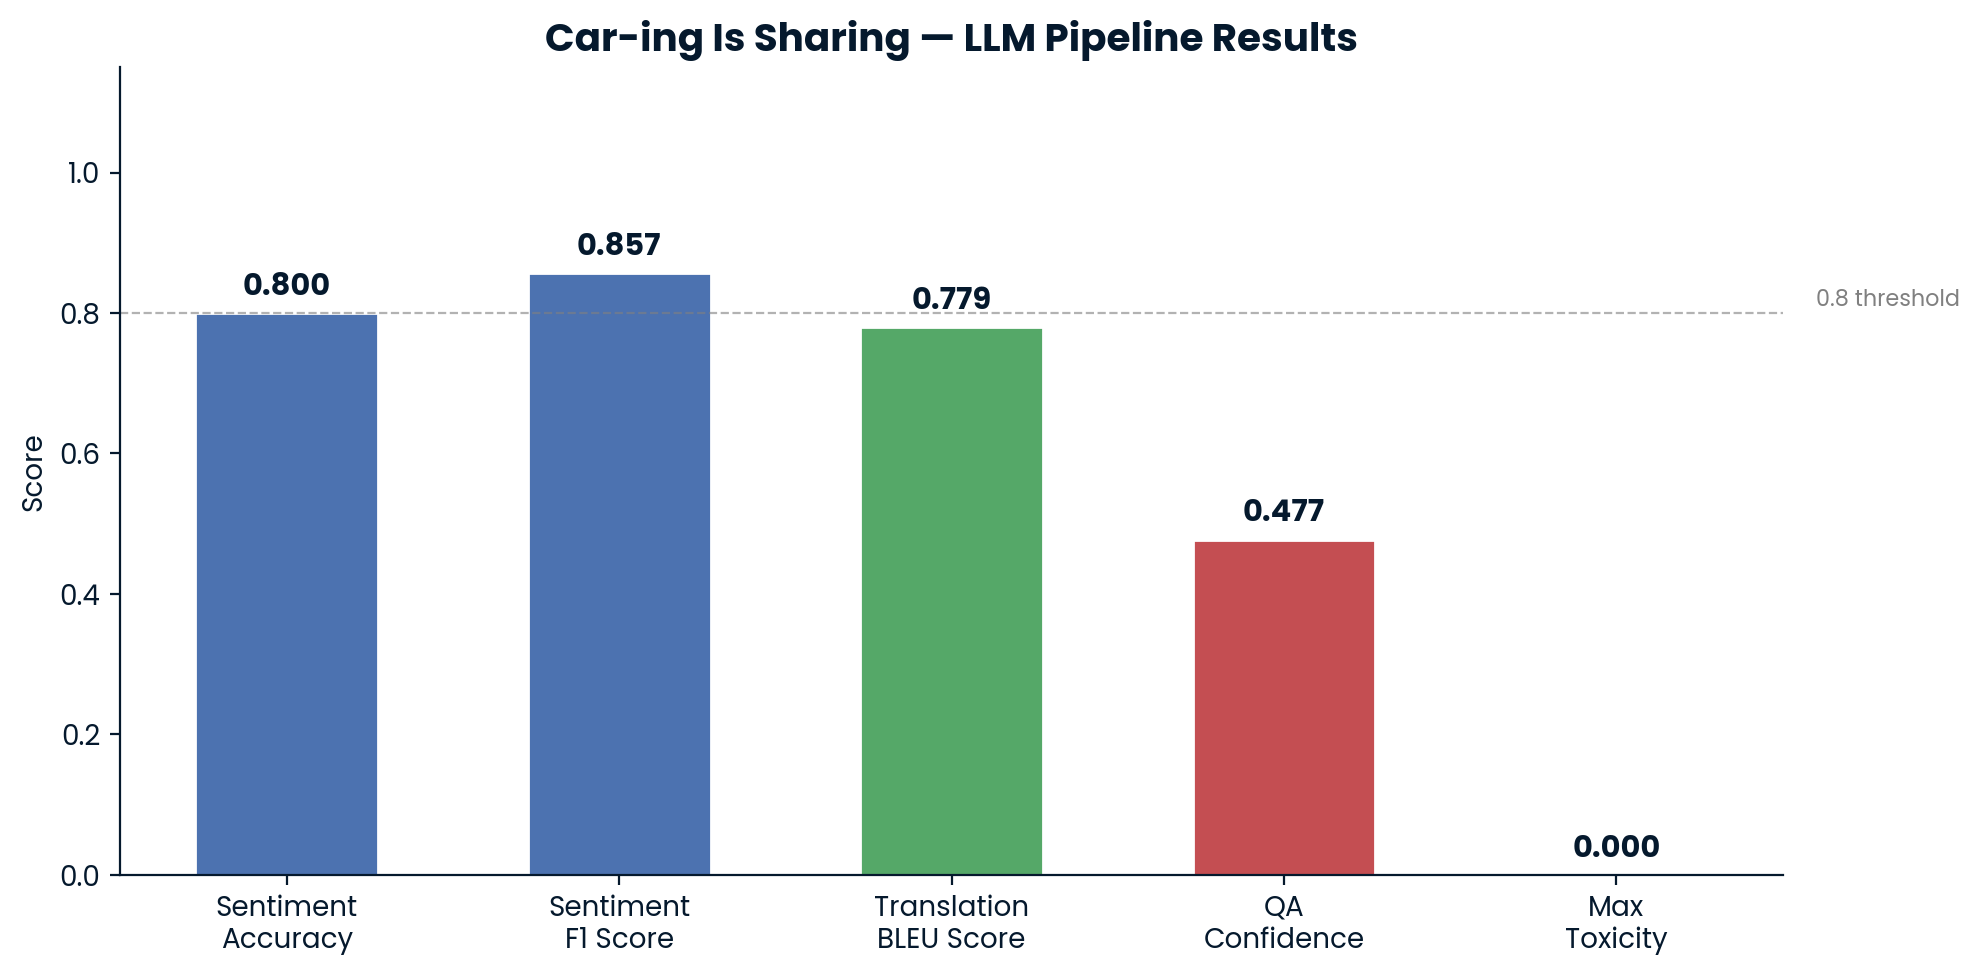


[Dashboard] Saved → results_dashboard.png

  CAR-ING IS SHARING — LLM PIPELINE | FINAL RESULTS
  Task 1 | Sentiment Accuracy   : 0.8000
  Task 1 | Sentiment F1 Score   : 0.8571
  Task 2 | BLEU Score           : 0.7794
  Task 2 | Translated Review    : Estoy muy satisfecho con mi Nissan NV SL 2014. Uso esta cami...
  Task 3 | QA Answer            : ride quality, reliability
  Task 3 | QA Confidence        : 0.4774
  Task 4 | Summarized Text      : The Nissan Rogue provides me with the desired SUV experience...
  Task 4 | Max Toxicity         : 0.0001


In [15]:
# Import necessary packages
import warnings
import pandas as pd
import torch
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate

from transformers import pipeline, logging
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")
logging.set_verbosity(logging.WARNING)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)


# DATA LOADING

df = pd.read_csv("data/car_reviews.csv", sep=";", encoding="utf-8-sig")

print("Dataset shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())


# Classify all reviews as POSITIVE or NEGATIVE, then score it

sentiment_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1,
)

predicted_labels = sentiment_classifier(df["Review"].tolist())

label_map = {"POSITIVE": 1, "NEGATIVE": 0}
predictions = [label_map[item["label"]] for item in predicted_labels]
true_labels = df["Class"].map(label_map).tolist()

accuracy_result = accuracy_score(true_labels, predictions)
f1_result = f1_score(true_labels, predictions, average="binary")

print(f"\n[Task 1] Accuracy : {accuracy_result:.4f}")
print(f"[Task 1] F1 Score : {f1_result:.4f}")

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NEGATIVE", "POSITIVE"],
    yticklabels=["NEGATIVE", "POSITIVE"],
    ax=ax,
)
ax.set_title("Sentiment Classification — Confusion Matrix")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("[Task 1] Confusion matrix saved → confusion_matrix.png")


# Translate the first two sentences of review[0], score with BLEU

first_review = df["Review"].iloc[0]
sentences = nltk.sent_tokenize(first_review)
text_to_translate = " ".join(sentences[:2])

print(f"\n[Task 2] Source text: {text_to_translate}")

translator = pipeline(
    "translation_en_to_es",
    model="Helsinki-NLP/opus-mt-en-es",
    device=0 if torch.cuda.is_available() else -1,
)

translated_output = translator(text_to_translate, max_length=512)
translated_review = translated_output[0]["translation_text"]

print(f"[Task 2] Translation : {translated_review}")

# Load reference translations
with open("data/reference_translations.txt", "r", encoding="utf-8") as f:
    raw_refs = [line.strip() for line in f.readlines() if line.strip()]

# List of per sentence
references = [[ref.split() for ref in raw_refs]]
hypothesis = [translated_review.split()]

bleu_metric = evaluate.load("bleu")
bleu_score = bleu_metric.compute(
    predictions=[translated_review],
    references=[raw_refs]
)
print(f"[Task 2] BLEU Score : {bleu_score}")


# Pull a direct answer from review[1] using MiniLM QA

second_review = df["Review"].iloc[1]

question = "What did he like about the brand?"
context = second_review

qa_pipeline = pipeline(
    "question-answering",
    model="deepset/minilm-uncased-squad2",
    device=0 if torch.cuda.is_available() else -1,
)

qa_output = qa_pipeline(question=question, context=context)
answer = qa_output["answer"]

print(f"\n[Task 3] Question   : {question}")
print(f"[Task 3] Answer     : {answer}")
print(f"[Task 3] Confidence : {qa_output['score']:.4f}")


# Summarize the last review, then check the output for bias signals

last_review = df["Review"].iloc[-1]

summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=0 if torch.cuda.is_available() else -1,
)

summary_output = summarizer(
    last_review,
    min_length=50,
    max_length=55,
    do_sample=False,
    truncation=True,
)
summarized_text = summary_output[0]["summary_text"]

print(f"\n[Task 4] Original : {last_review[:200]}...")
print(f"[Task 4] Summary  : {summarized_text}")

# Toxicity — any harmful signals
toxicity_metric = evaluate.load("toxicity", module_type="measurement")
tox_result = toxicity_metric.compute(predictions=[summarized_text])
max_toxicity = max(tox_result["toxicity"])

# Regard — sentiment polarity
regard_metric = evaluate.load("regard", module_type="measurement")
regard_result = regard_metric.compute(data=[summarized_text])

print(f"[Task 4] Max Toxicity : {max_toxicity:.4f}")
print(f"[Task 4] Regard       : {regard_result['regard']}")


# RESULTS DASHBOARD

metrics = {
    "Sentiment\nAccuracy": accuracy_result,
    "Sentiment\nF1 Score": f1_result,
    "Translation\nBLEU Score": bleu_score["bleu"],
    "QA\nConfidence": qa_output["score"],
    "Max\nToxicity": max_toxicity,
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    metrics.keys(),
    metrics.values(),
    color=["#4C72B0", "#4C72B0", "#55A868", "#C44E52", "#8172B2"],
    edgecolor="white",
    width=0.55,
)

for bar, val in zip(bars, metrics.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_ylim(0, 1.15)
ax.set_title("Car-ing Is Sharing — LLM Pipeline Results", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.axhline(y=0.8, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(4.6, 0.81, "0.8 threshold", fontsize=8, color="gray")
sns.despine()
plt.tight_layout()
plt.savefig("results_dashboard.png", dpi=150)
plt.show()
print("\n[Dashboard] Saved → results_dashboard.png")


# FINAL PRINT

print("\n" + "=" * 58)
print("  CAR-ING IS SHARING — LLM PIPELINE | FINAL RESULTS")
print("=" * 58)
print(f"  Task 1 | Sentiment Accuracy   : {accuracy_result:.4f}")
print(f"  Task 1 | Sentiment F1 Score   : {f1_result:.4f}")
print(f"  Task 2 | BLEU Score           : {bleu_score['bleu']:.4f}")
print(f"  Task 2 | Translated Review    : {translated_review[:60]}...")
print(f"  Task 3 | QA Answer            : {answer}")
print(f"  Task 3 | QA Confidence        : {qa_output['score']:.4f}")
print(f"  Task 4 | Summarized Text      : {summarized_text[:60]}...")
print(f"  Task 4 | Max Toxicity         : {max_toxicity:.4f}")
print("=" * 58)